# Notebook 4 — One Transfer Step

**Course: Cross-Corridor Capacity Analysis with pandapower (Svedala grid)**

Before automating the sweep, we need a clean primitive: **apply one transfer**
**increment and observe the result**.

## Learning objectives

- Apply a generation shift `+ΔP` from source to sink using GSK.
- Run the power flow on the new dispatch.
- Read off the new corridor flow and the most-stressed monitored elements.
- Restore the base dispatch cleanly using `copy.deepcopy`.

## 4.1  Load everything

In [1]:
import json, copy
import pandapower as pp
import pandas as pd
import numpy as np

net = pp.from_json('data/svedala_base.json')
pp.runpp(net)

with open('data/corridor.json') as f:
    corridor = json.load(f)

GSK_A = pd.Series({int(k): float(v) for k, v in corridor['gsk_a'].items()})
GSK_B = pd.Series({int(k): float(v) for k, v in corridor['gsk_b'].items()})
LINE_DIR  = [tuple(x) for x in corridor['corridor_lines']]
TRAFO_DIR = [tuple(x) for x in corridor['corridor_trafos']]
P0        = corridor['base_flow_a_to_b']
ZONE_SOURCE = corridor['zone_source']
ZONE_SINK   = corridor['zone_sink']

print(f'Base flow {ZONE_SOURCE} → {ZONE_SINK}: {P0:+.2f} MW')

numba cannot be imported and numba functions are disabled.
Probably the execution is slow.
Please install numba to gain a massive speedup.
(or if you prefer slow execution, set the flag numba=False to avoid this warning!)


Base flow ZON_NORR → ZON_MITT: +2498.28 MW


## 4.2  The transfer-step primitive

The function takes a fresh deep-copy of the base net, modifies generator
setpoints in-place, runs the power flow, and reports.

Generator setpoints are clipped to `[min_p_mw, max_p_mw]` to model saturation:
if a generator can't take its full GSK share, the rest spills onto the slack.

In [2]:
def corridor_flow(net, line_dir, trafo_dir):
    p = 0.0
    for idx, d in line_dir:
        p += d * net.res_line.at[idx, 'p_from_mw']
    for idx, d in trafo_dir:
        p += d * net.res_trafo.at[idx, 'p_hv_mw']
    return p

def apply_transfer_step(base_net, delta_mw, gsk_a, gsk_b,
                        line_dir, trafo_dir,
                        v_min=0.95, v_max=1.05,
                        line_limit=100.0, trafo_limit=100.0):
    """Apply a one-shot generation shift of delta_mw and analyse."""
    net = copy.deepcopy(base_net)

    # Saturating shift
    for g, k in gsk_a.items():
        new_p = net.gen.at[g, 'p_mw'] + k * delta_mw
        if not np.isnan(net.gen.at[g, 'max_p_mw']):
            new_p = min(new_p, net.gen.at[g, 'max_p_mw'])
        if not np.isnan(net.gen.at[g, 'min_p_mw']):
            new_p = max(new_p, net.gen.at[g, 'min_p_mw'])
        net.gen.at[g, 'p_mw'] = new_p
    for g, k in gsk_b.items():
        new_p = net.gen.at[g, 'p_mw'] - k * delta_mw
        if not np.isnan(net.gen.at[g, 'max_p_mw']):
            new_p = min(new_p, net.gen.at[g, 'max_p_mw'])
        if not np.isnan(net.gen.at[g, 'min_p_mw']):
            new_p = max(new_p, net.gen.at[g, 'min_p_mw'])
        net.gen.at[g, 'p_mw'] = new_p

    try:
        pp.runpp(net)
    except pp.LoadflowNotConverged:
        return {'delta_request_mw': delta_mw, 'converged': False,
                'corridor_flow': None, 'max_line_loading': None,
                'min_voltage': None, 'max_voltage': None}

    return {
        'delta_request_mw':  delta_mw,
        'converged':         True,
        'corridor_flow':     corridor_flow(net, line_dir, trafo_dir),
        'max_line_loading':  float(net.res_line.loading_percent.max()),
        'max_trafo_loading': float(net.res_trafo.loading_percent.max())
                              if len(net.res_trafo) else 0.0,
        'min_voltage':       float(net.res_bus.vm_pu.min()),
        'max_voltage':       float(net.res_bus.vm_pu.max()),
    }

## 4.3  Try a single step

In [3]:
result = apply_transfer_step(net, 200.0, GSK_A, GSK_B, LINE_DIR, TRAFO_DIR)
for k, v in result.items():
    print(f'  {k:<20} {v}')

numba cannot be imported and numba functions are disabled.
Probably the execution is slow.
Please install numba to gain a massive speedup.
(or if you prefer slow execution, set the flag numba=False to avoid this warning!)


  delta_request_mw     200.0
  converged            True
  corridor_flow        2703.27290517133
  max_line_loading     92.32895743210806
  max_trafo_loading    107.79592316442832
  min_voltage          0.8552091793635124
  max_voltage          1.0801941498729601


Notice that the *achieved* corridor flow is not exactly `P0 + 200` MW — losses
change with flow patterns and the slack absorbs the difference, plus generators
may saturate. That's why we always **measure** the corridor flow rather than
trusting the requested ΔP.

## 4.4  Sanity sweep — a handful of small steps

In [4]:
rows = []
for delta in [0, 50, 100, 200, 300, 500, 700, 1000]:
    rows.append(apply_transfer_step(net, delta, GSK_A, GSK_B,
                                    LINE_DIR, TRAFO_DIR))
df = pd.DataFrame(rows)
df.round(3)

numba cannot be imported and numba functions are disabled.
Probably the execution is slow.
Please install numba to gain a massive speedup.
(or if you prefer slow execution, set the flag numba=False to avoid this warning!)
numba cannot be imported and numba functions are disabled.
Probably the execution is slow.
Please install numba to gain a massive speedup.
(or if you prefer slow execution, set the flag numba=False to avoid this warning!)
numba cannot be imported and numba functions are disabled.
Probably the execution is slow.
Please install numba to gain a massive speedup.
(or if you prefer slow execution, set the flag numba=False to avoid this warning!)
numba cannot be imported and numba functions are disabled.
Probably the execution is slow.
Please install numba to gain a massive speedup.
(or if you prefer slow execution, set the flag numba=False to avoid this warning!)
numba cannot be imported and numba functions are disabled.
Probably the execution is slow.
Please install numba 

,delta_request_mw,converged,corridor_flow,max_line_loading,max_trafo_loading,min_voltage,max_voltage
0,0,True,2498.282,89.154,110.284,0.860,1.082
1,50,True,2549.148,89.855,109.616,0.859,1.082
2,100,True,2600.260,90.564,108.977,0.858,1.081
3,200,True,2703.273,92.329,107.796,0.855,1.080
4,300,True,2807.447,94.779,106.758,0.853,1.079
5,500,True,3020.122,99.907,109.688,0.846,1.076
6,700,True,3240.549,105.427,136.127,0.838,1.072
7,1000,True,3600.326,115.281,217.394,0.820,1.062


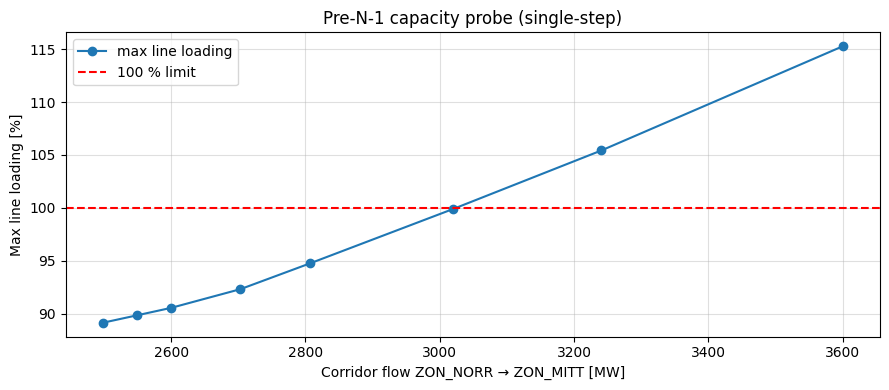

In [5]:
import matplotlib.pyplot as plt
ok = df[df.converged]
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(ok.corridor_flow, ok.max_line_loading, 'o-', label='max line loading')
ax.axhline(100, color='red', linestyle='--', label='100 % limit')
ax.set_xlabel(f'Corridor flow {ZONE_SOURCE} → {ZONE_SINK} [MW]')
ax.set_ylabel('Max line loading [%]')
ax.set_title('Pre-N-1 capacity probe (single-step)')
ax.grid(True, alpha=0.4); ax.legend()
plt.tight_layout(); plt.show()

## 4.5  Reverse direction (sink → source)

Capacity is direction-dependent. Test by passing negative `delta_mw`.

In [6]:
for delta in [-100, -300, -500]:
    r = apply_transfer_step(net, delta, GSK_A, GSK_B, LINE_DIR, TRAFO_DIR)
    if r['converged']:
        print(f'ΔP = {delta:+5} MW → corridor flow {r["corridor_flow"]:+8.2f} MW, '
              f'max line loading {r["max_line_loading"]:5.1f} %')
    else:
        print(f'ΔP = {delta:+5} MW → did not converge')

numba cannot be imported and numba functions are disabled.
Probably the execution is slow.
Please install numba to gain a massive speedup.
(or if you prefer slow execution, set the flag numba=False to avoid this warning!)
numba cannot be imported and numba functions are disabled.
Probably the execution is slow.
Please install numba to gain a massive speedup.
(or if you prefer slow execution, set the flag numba=False to avoid this warning!)
numba cannot be imported and numba functions are disabled.
Probably the execution is slow.
Please install numba to gain a massive speedup.
(or if you prefer slow execution, set the flag numba=False to avoid this warning!)


ΔP =  -100 MW → corridor flow +2446.98 MW, max line loading  88.6 %
ΔP =  -300 MW → corridor flow +2371.85 MW, max line loading  87.9 %
ΔP =  -500 MW → corridor flow +2318.21 MW, max line loading  87.4 %


## 4.6  Exercises

1. Find the **smallest** positive `ΔP` (resolution 10 MW, then bisect to 1 MW)
   that produces a *line* violation. Report the limiting line.
2. Find the **smallest** positive `ΔP` that produces a *voltage* violation.
   Which limit binds first — thermal or voltage? In Sweden, long
   NORR → MITT transfers historically bind on voltage. Does Svedala behave
   that way?
3. Replace Pmax-proportional GSK in the source zone with **headroom-
   proportional** GSK (each gen contributes proportionally to `max_p_mw - p_mw`)
   and rerun the small sweep. Does the corridor flow vs ΔP relation change?

In [9]:
# Exercise 1 — Smallest ΔP (1 MW resolution) that causes a line overload

# Step 1: coarse search at 100 MW resolution
delta_line = None
for delta in range(100, 3001, 100):
    r = apply_transfer_step(net, delta, GSK_A, GSK_B, LINE_DIR, TRAFO_DIR)
    if not r['converged'] or r['max_line_loading'] > 100.0:
        delta_line = delta
        break

print(f'Coarse bracket: [{delta_line - 100}, {delta_line}] MW')

# Step 2: bisect to 1 MW resolution within the 100 MW bracket
lo, hi = delta_line - 100, delta_line
while hi - lo > 1:
    mid = (lo + hi) // 2
    r = apply_transfer_step(net, mid, GSK_A, GSK_B, LINE_DIR, TRAFO_DIR)
    if r['converged'] and r['max_line_loading'] > 100.0:
        hi = mid
    else:
        lo = mid

delta_line = hi
r_lim = apply_transfer_step(net, delta_line, GSK_A, GSK_B, LINE_DIR, TRAFO_DIR)
print(f'First line overload at ΔP = {delta_line} MW')
print(f'  Corridor flow : {r_lim["corridor_flow"]:+.1f} MW')
print(f'  Max loading   : {r_lim["max_line_loading"]:.1f} %')

# Step 3: identify the limiting line (re-apply the shift and run PF once more)
net_lim = copy.deepcopy(net)
for g, k in GSK_A.items():
    p = net_lim.gen.at[g, 'p_mw'] + k * delta_line
    if not np.isnan(net_lim.gen.at[g, 'max_p_mw']): p = min(p, net_lim.gen.at[g, 'max_p_mw'])
    if not np.isnan(net_lim.gen.at[g, 'min_p_mw']): p = max(p, net_lim.gen.at[g, 'min_p_mw'])
    net_lim.gen.at[g, 'p_mw'] = p
for g, k in GSK_B.items():
    p = net_lim.gen.at[g, 'p_mw'] - k * delta_line
    if not np.isnan(net_lim.gen.at[g, 'max_p_mw']): p = min(p, net_lim.gen.at[g, 'max_p_mw'])
    if not np.isnan(net_lim.gen.at[g, 'min_p_mw']): p = max(p, net_lim.gen.at[g, 'min_p_mw'])
    net_lim.gen.at[g, 'p_mw'] = p
pp.runpp(net_lim)

worst_idx = net_lim.res_line.loading_percent.idxmax()
print(f'  Limiting line : {net_lim.line.at[worst_idx, "name"]}  '
      f'({net_lim.res_line.at[worst_idx, "loading_percent"]:.1f} %)')


numba cannot be imported and numba functions are disabled.
Probably the execution is slow.
Please install numba to gain a massive speedup.
(or if you prefer slow execution, set the flag numba=False to avoid this warning!)
numba cannot be imported and numba functions are disabled.
Probably the execution is slow.
Please install numba to gain a massive speedup.
(or if you prefer slow execution, set the flag numba=False to avoid this warning!)
numba cannot be imported and numba functions are disabled.
Probably the execution is slow.
Please install numba to gain a massive speedup.
(or if you prefer slow execution, set the flag numba=False to avoid this warning!)
numba cannot be imported and numba functions are disabled.
Probably the execution is slow.
Please install numba to gain a massive speedup.
(or if you prefer slow execution, set the flag numba=False to avoid this warning!)
numba cannot be imported and numba functions are disabled.
Probably the execution is slow.
Please install numba 

Coarse bracket: [500, 600] MW


numba cannot be imported and numba functions are disabled.
Probably the execution is slow.
Please install numba to gain a massive speedup.
(or if you prefer slow execution, set the flag numba=False to avoid this warning!)
numba cannot be imported and numba functions are disabled.
Probably the execution is slow.
Please install numba to gain a massive speedup.
(or if you prefer slow execution, set the flag numba=False to avoid this warning!)
numba cannot be imported and numba functions are disabled.
Probably the execution is slow.
Please install numba to gain a massive speedup.
(or if you prefer slow execution, set the flag numba=False to avoid this warning!)
numba cannot be imported and numba functions are disabled.
Probably the execution is slow.
Please install numba to gain a massive speedup.
(or if you prefer slow execution, set the flag numba=False to avoid this warning!)
numba cannot be imported and numba functions are disabled.
Probably the execution is slow.
Please install numba 

First line overload at ΔP = 504 MW
  Corridor flow : +3024.4 MW
  Max loading   : 100.0 %
  Limiting line : AL7  (100.0 %)


In [10]:
# Exercise 2 — Smallest ΔP that introduces a NEW voltage violation
#
# The base case has buses outside ±5 % due to two model limitations:
#   1. Structural under-voltages on 135 kV radial load buses (NYSTAD, YTTERFORSEN,
#      SYDKÖPING, NORRÅS) — missing reactive compensation in the CIM export.
#   2. Generator-collector over-voltages at 135 kV (AGGAN, STUPET, …) — off-nominal
#      CIM winding ratios relative to bus vn_kv.
# Strategy: classify *transmission* buses (≥ 100 kV) that are within the ±5 % band
# at base case as 'ok', then find the first ΔP that moves any of them outside the
# limit. This mirrors real capacity-assessment practice and avoids artefacts from
# generator terminal buses at low kV.

pp.runpp(net)   # refresh base-case results
base_vm  = net.res_bus.vm_pu.copy()
tx_mask  = net.bus.vn_kv >= 100          # transmission buses only
ok_buses = base_vm.index[(base_vm >= 0.95) & (base_vm <= 1.05) & tx_mask]

n_tx_out = int(tx_mask.sum()) - len(ok_buses)
print(f'Transmission buses: {int(tx_mask.sum())}')
print(f'  already outside \u00b15 %: {n_tx_out}  (pre-existing model limitation)')
print(f'  within limits:          {len(ok_buses)}  (these are monitored)')
tight_idx = base_vm[ok_buses].idxmin()
print(f'  tightest margin: {net.bus.at[tight_idx, "name"]} '
      f'@ {base_vm[tight_idx]:.4f} pu\n')


def _pf_with_transfer(delta):
    """Deep-copy net, apply transfer shift, run PF. Returns (converged, net_copy)."""
    n = copy.deepcopy(net)
    for g, k in GSK_A.items():
        p = n.gen.at[g, 'p_mw'] + k * delta
        if not np.isnan(n.gen.at[g, 'max_p_mw']): p = min(p, n.gen.at[g, 'max_p_mw'])
        if not np.isnan(n.gen.at[g, 'min_p_mw']): p = max(p, n.gen.at[g, 'min_p_mw'])
        n.gen.at[g, 'p_mw'] = p
    for g, k in GSK_B.items():
        p = n.gen.at[g, 'p_mw'] - k * delta
        if not np.isnan(n.gen.at[g, 'max_p_mw']): p = min(p, n.gen.at[g, 'max_p_mw'])
        if not np.isnan(n.gen.at[g, 'min_p_mw']): p = max(p, n.gen.at[g, 'min_p_mw'])
        n.gen.at[g, 'p_mw'] = p
    try:
        pp.runpp(n)
        return True, n
    except pp.LoadflowNotConverged:
        return False, None


def _has_new_viol(n):
    """True if any previously-ok transmission bus has crossed a voltage limit."""
    vok = n.res_bus.loc[ok_buses, 'vm_pu']
    return bool((vok < 0.95).any() or (vok > 1.05).any())


# Step 1: coarse search at 100 MW steps
coarse_hi = None
for delta in range(100, 3001, 100):
    ok, n_test = _pf_with_transfer(delta)
    if not ok or _has_new_viol(n_test):
        coarse_hi = delta
        break

if coarse_hi is None:
    print('No new voltage violation up to 3 000 MW')
else:
    print(f'Coarse bracket: [{coarse_hi - 100}, {coarse_hi}] MW')

    # Step 2: bisect to 1 MW
    lo, hi = coarse_hi - 100, coarse_hi
    while hi - lo > 1:
        mid = (lo + hi) // 2
        ok, n_test = _pf_with_transfer(mid)
        if not ok or _has_new_viol(n_test):
            hi = mid
        else:
            lo = mid

    delta_volt = hi
    _, n_viol = _pf_with_transfer(delta_volt)
    vok = n_viol.res_bus.loc[ok_buses, 'vm_pu']
    first_idx = vok.idxmin()

    print(f'\nFirst NEW violation at \u0394P = {delta_volt} MW')
    print(f'  Limiting bus    : {net.bus.at[first_idx, "name"]}')
    print(f'  Voltage         : {vok[first_idx]:.4f} pu '
          f'(was {base_vm[first_idx]:.4f} pu at base)')
    print(f'  Max line loading: {n_viol.res_line.loading_percent.max():.1f} %')

    if delta_volt < delta_line:
        print(f'\n\u2192 Voltage binds FIRST at \u0394P = {delta_volt} MW, '
              f'thermal at \u0394P = {delta_line} MW.')
        print('  Svedala behaves like the real Nordic system: reactive-voltage '
              'limits are the tighter constraint on long NORR \u2192 MITT transfers.')
    else:
        print(f'\n\u2192 Thermal ({delta_line} MW) binds before voltage ({delta_volt} MW).')


numba cannot be imported and numba functions are disabled.
Probably the execution is slow.
Please install numba to gain a massive speedup.
(or if you prefer slow execution, set the flag numba=False to avoid this warning!)
numba cannot be imported and numba functions are disabled.
Probably the execution is slow.
Please install numba to gain a massive speedup.
(or if you prefer slow execution, set the flag numba=False to avoid this warning!)
numba cannot be imported and numba functions are disabled.
Probably the execution is slow.
Please install numba to gain a massive speedup.
(or if you prefer slow execution, set the flag numba=False to avoid this warning!)
numba cannot be imported and numba functions are disabled.
Probably the execution is slow.
Please install numba to gain a massive speedup.
(or if you prefer slow execution, set the flag numba=False to avoid this warning!)


Transmission buses: 32
  already outside ±5 %: 9  (pre-existing model limitation)
  within limits:          23  (these are monitored)
  tightest margin: HÄSTSJÖ RT132_135.0kV @ 0.9501 pu

Coarse bracket: [0, 100] MW


numba cannot be imported and numba functions are disabled.
Probably the execution is slow.
Please install numba to gain a massive speedup.
(or if you prefer slow execution, set the flag numba=False to avoid this warning!)
numba cannot be imported and numba functions are disabled.
Probably the execution is slow.
Please install numba to gain a massive speedup.
(or if you prefer slow execution, set the flag numba=False to avoid this warning!)
numba cannot be imported and numba functions are disabled.
Probably the execution is slow.
Please install numba to gain a massive speedup.
(or if you prefer slow execution, set the flag numba=False to avoid this warning!)
numba cannot be imported and numba functions are disabled.
Probably the execution is slow.
Please install numba to gain a massive speedup.
(or if you prefer slow execution, set the flag numba=False to avoid this warning!)
numba cannot be imported and numba functions are disabled.
Probably the execution is slow.
Please install numba 


First NEW violation at ΔP = 26 MW
  Limiting bus    : HÄSTSJÖ RT132_135.0kV
  Voltage         : 0.9500 pu (was 0.9501 pu at base)
  Max line loading: 89.5 %

→ Voltage binds FIRST at ΔP = 26 MW, thermal at ΔP = 504 MW.
  Svedala behaves like the real Nordic system: reactive-voltage limits are the tighter constraint on long NORR → MITT transfers.


---

✅ **Checkpoint reached.** Transfer-step primitive working.

Continue to [Notebook 5 — Iterative Capacity Probing](05_capacity_sweep.ipynb).